In [78]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
from astropy.visualization import hist
from scipy.stats import norm
import scipy
import pandas as pd
from scipy.stats import norm
import corner

In [73]:
import dynesty

from dynesty import utils as dyfunc
from dynesty import plotting as dyplot

In [50]:
path = '../solutions/transient.npy'

In [51]:
data = np.load(path)
np.shape(data)
times = []
F = []
sF = []
for i in range(100):
    times = np.append(times,data[i][0])
    F = np.append(F,data[i][1])
    sF = np.append(sF,data[i][2])

In [118]:
def burst(theta,t):
    A,b,t0,alpha=theta 
    return np.where(t<t0,b,b+A*np.exp(-alpha*(t-t0)))

def gprofile(theta,t):
    A,b,t0,sigmaW=theta     
    return b+A*np.exp(-(((t-t0)/sigmaW)**2 ) / 2)

In [109]:
t0min,t0max = 0,100
Amin,Amax=0,50
bmin,bmax=0,50
alphamin,alphamax=np.exp(-5),np.exp(5)

sigmaWmin,sigmaWmax=np.exp(-2),np.exp(2)

In [119]:
def loglike(theta, data, model):
    x, y, sigma_y = data.T
    if model =='burst':
        y_fit = burst(theta, x)
    elif model == 'gprofile':
        y_fit = gprofile(theta, x)
        
    return -0.5 * np.sum((y-y_fit)**2 / sigma_y**2 ) 


def ptform(u,model):
    x = np.array(u)  # copy u

    x[0] = scipy.stats.uniform(loc=Amin,scale=Amax-Amin).ppf(u[0])
    x[1] = scipy.stats.uniform(loc=bmin,scale=bmax-bmin).ppf(u[1])
    x[2] = scipy.stats.uniform(loc=t0min,scale=t0max-t0min).ppf(u[2])
   
    if model =='burst':
        x[3] = scipy.stats.loguniform.ppf(u[3],alphamin,alphamax)
    elif model =='gprofile':
        x[3] = scipy.stats.loguniform.ppf(u[3],sigmaWmin,sigmaWmax)
    return x

In [120]:
ndim = 4

In [121]:
import warnings

# Burst model

In [124]:
with warnings.catch_warnings():
    # Those warnings come from regions where the likelihood is ~zero
    warnings.simplefilter("ignore", category=RuntimeWarning)

    # Define and run sampler
    sampler = dynesty.NestedSampler(loglike, ptform, ndim,logl_args=[data,'burst'],ptform_args=['burst'],nlive=300)
    sampler.run_nested()
    sresults = sampler.results

4796it [02:36, 30.57it/s, +300 | bound: 175 | nc: 1 | ncall: 76170 | eff(%):  6.717 | loglstar:   -inf < -48.759 <    inf | logz: -63.466 +/-  0.214 | dlogz:  0.001 >  0.309]


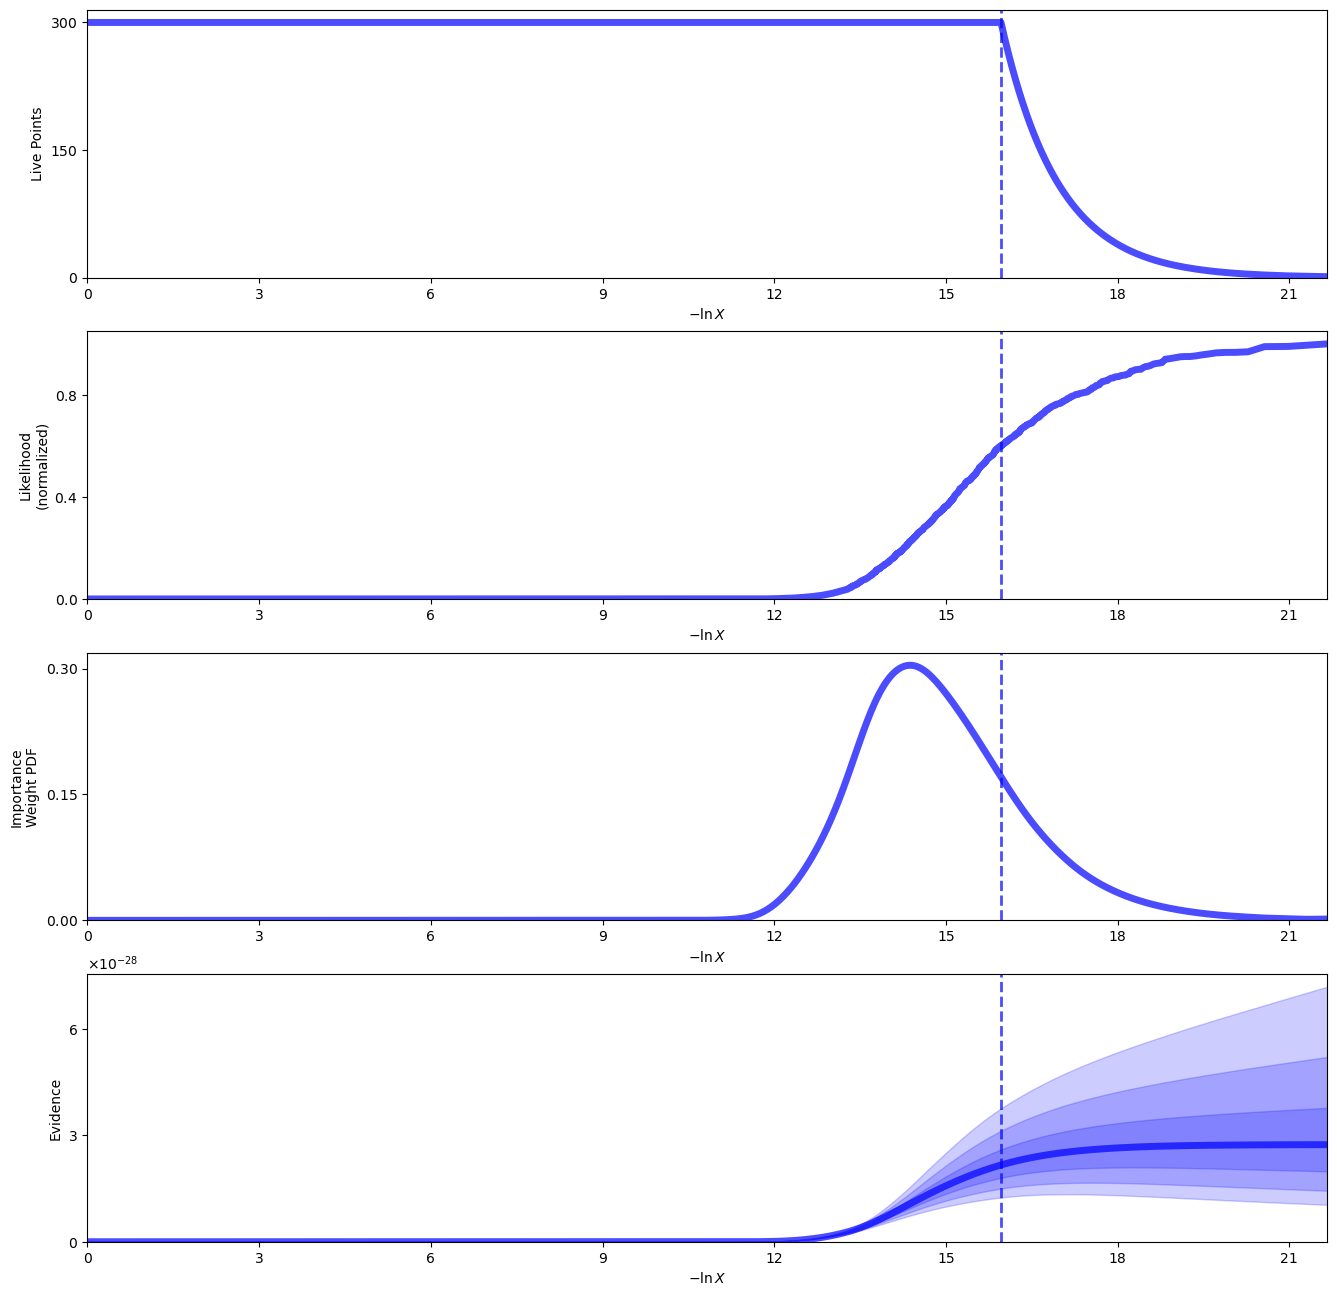

In [125]:
rfig, raxes = dyplot.runplot(sresults)

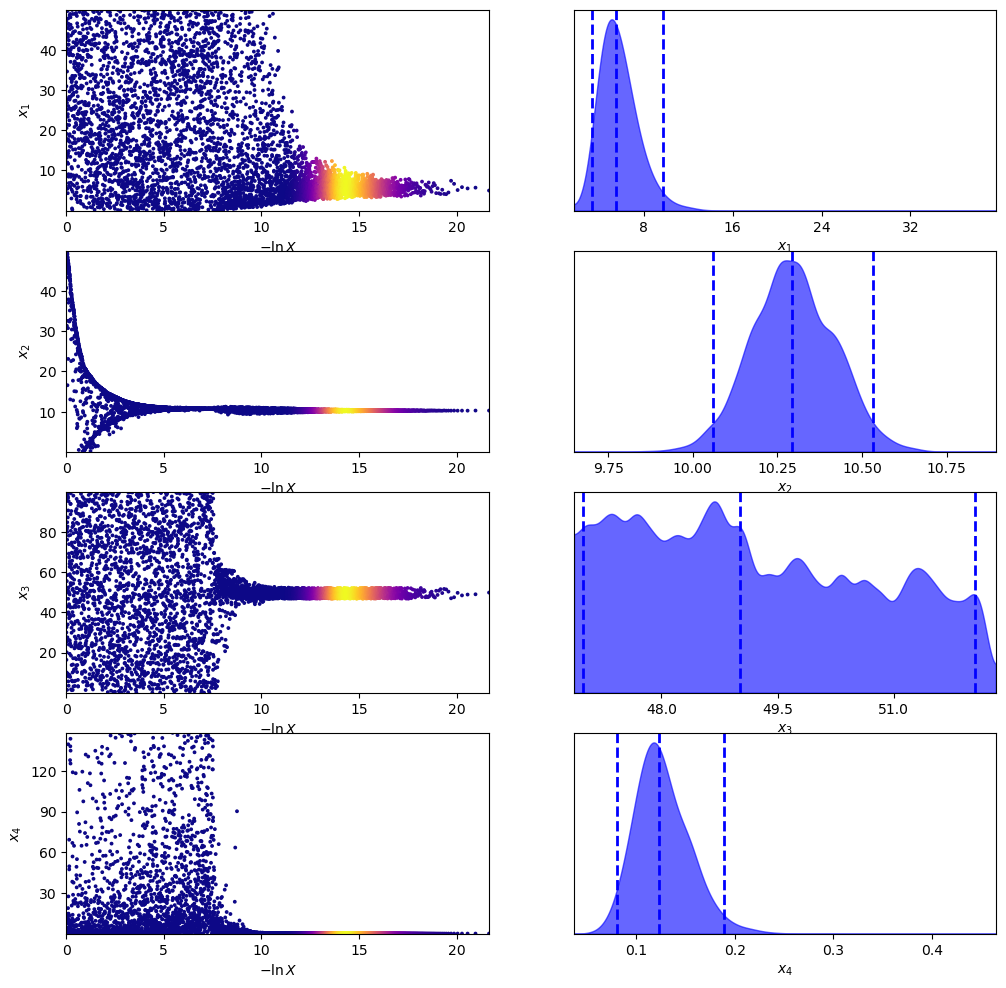

In [126]:
tfig, taxes = dyplot.traceplot(sresults)

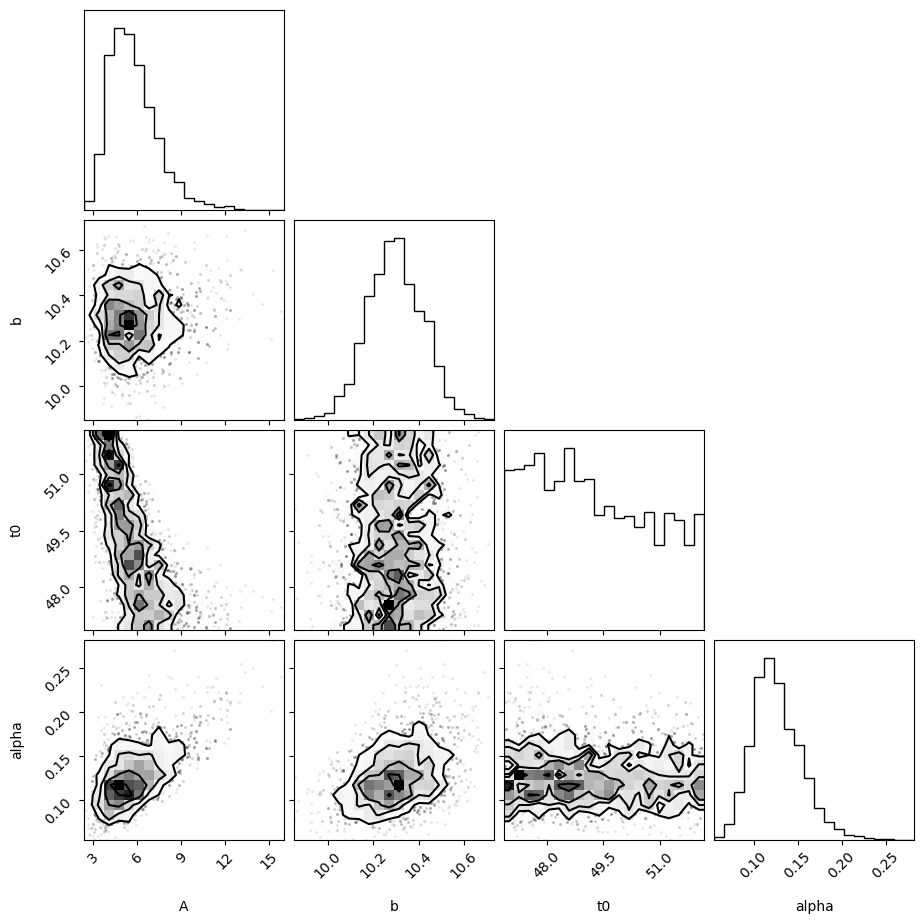

In [127]:
samples = sresults.samples  # samples
weights = np.exp(sresults.logwt - sresults.logz[-1])  # normalized weights

labels = ["A","b","t0","alpha"]

samples_equal = dyfunc.resample_equal(samples, weights)
corner.corner(samples_equal,labels=labels);

In [128]:
quantiles = [dyfunc.quantile(samps, [0.05, 0.5, 0.95], weights=weights)
             for samps in samples.T]
for q,l in zip(quantiles,labels):
    low,med,up=q
    print(l+"   "+str(med)+" +"+str(up-med)+" -"+str(med-low))

A   5.474036965795805 +3.3981641637008684 -1.8737486030680093
b   10.294219271358653 +0.20035317706293476 -0.190591690193191
t0   49.011778098004164 +2.8146771034672042 -1.9252744935530401
alpha   0.12282906621543675 +0.05344971609788231 -0.035951010546833126


In [129]:
sresults.summary()

Summary
nlive: 300
niter: 4796
ncall: 75870
eff(%):  6.717
logz: -63.466 +/-  0.322


# Gaussian

In [131]:
with warnings.catch_warnings():
    # Those warnings come from regions where the likelihood is ~zero
    warnings.simplefilter("ignore", category=RuntimeWarning)
    
    sampler = dynesty.NestedSampler(loglike, ptform, ndim,logl_args=[data,'gprofile'],ptform_args=['gprofile'],nlive=300)
    sampler.run_nested()
    sresults2 = sampler.results

2540it [01:30,  2.23it/s, bound: 88 | nc: 129 | ncall: 43405 | eff(%):  5.852 | loglstar:   -inf < -86.644 <    inf | logz: -94.707 +/-  0.153 | dlogz: 32.039 >  0.309]/home/elisa/miniconda3/envs/fermipy/lib/python3.9/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
2547it [01:40,  1.31it/s, bound: 90 | nc: 71 | ncall: 48583 | eff(%):  5.243 | loglstar:   -inf < -86.455 <    inf | logz: -94.690 +/-  0.153 | dlogz: 31.999 >  0.309]/home/elisa/miniconda3/envs/fermipy/lib/python3.9/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapp

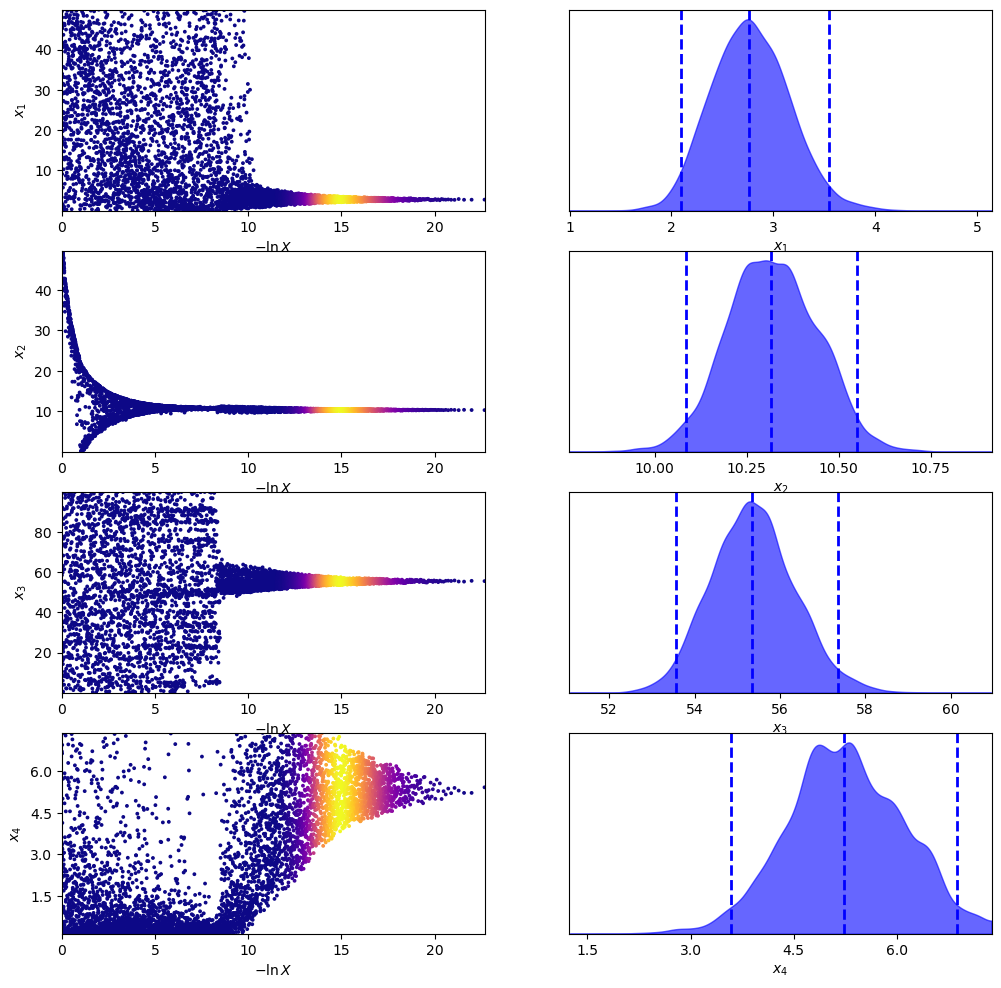

In [132]:
tfig, taxes = dyplot.traceplot(sresults2)

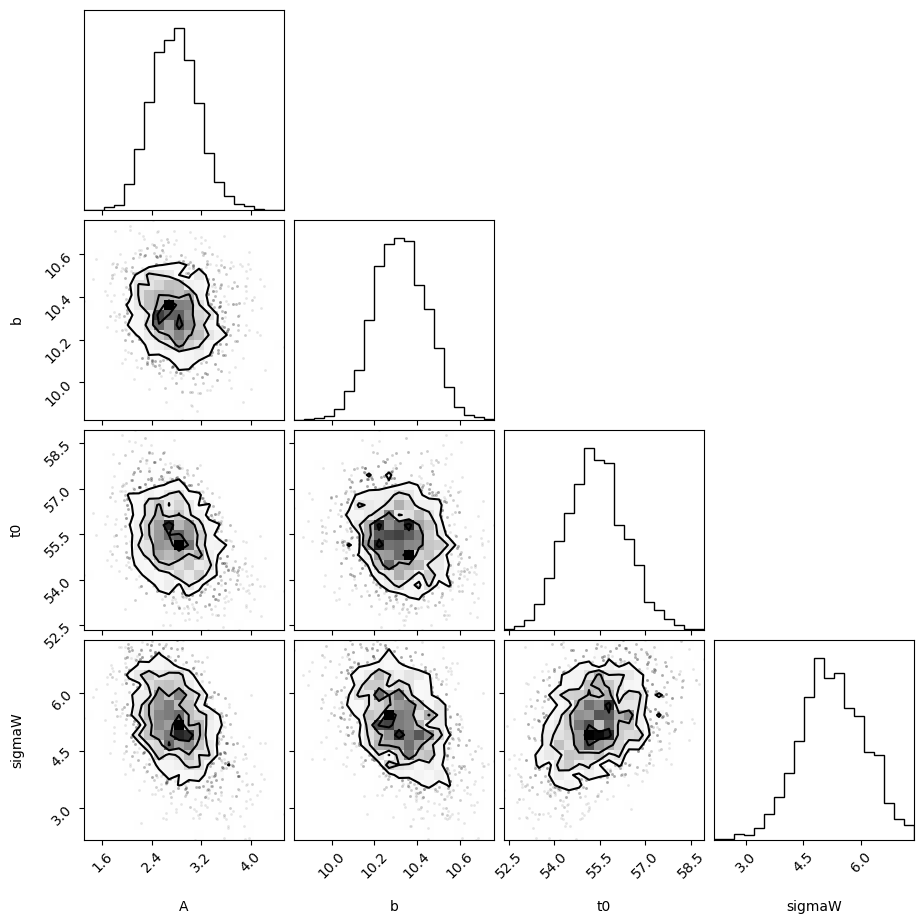

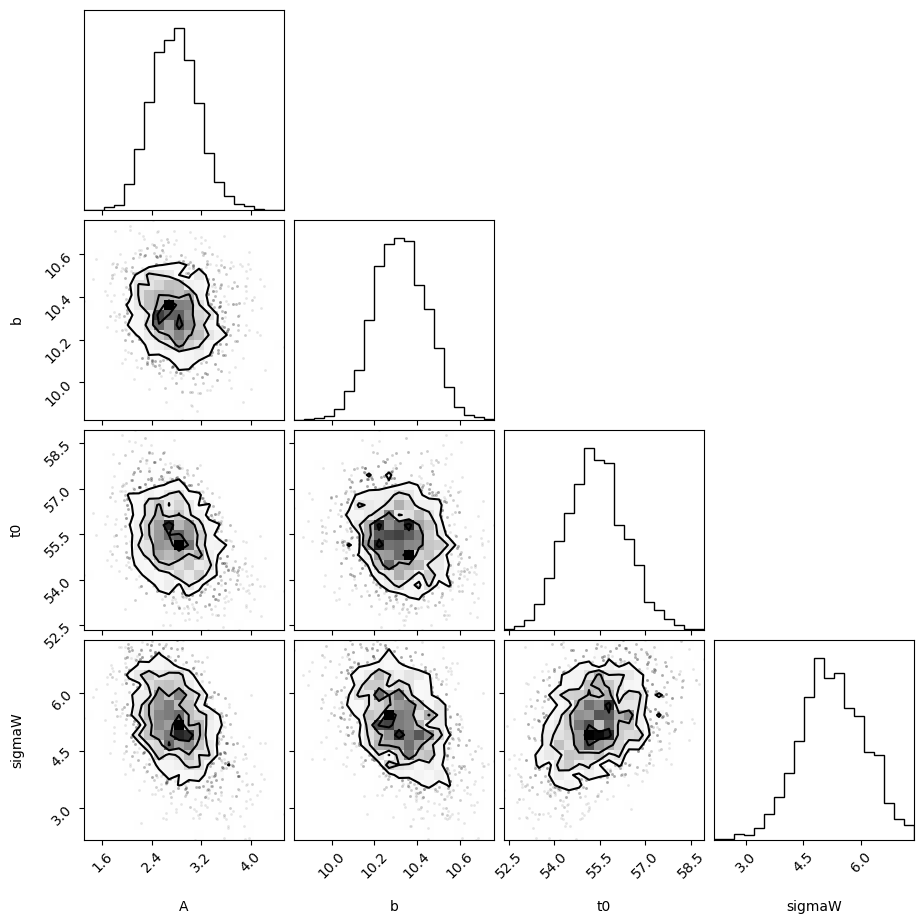

In [133]:
samples = sresults2.samples  # samples
weights = np.exp(sresults2.logwt - sresults2.logz[-1])  # normalized weights

labels = ["A","b","t0","sigmaW"]

samples_equal = dyfunc.resample_equal(samples, weights)
corner.corner(samples_equal,labels=labels)

In [134]:
sresults2.summary()

Summary
nlive: 300
niter: 5099
ncall: 78650
eff(%):  6.865
logz: -68.178 +/-  0.326


In [135]:
np.exp(sresults.logz[-1])/np.exp(sresults2.logz[-1])

111.26203785094542